#Boxplots

In [131]:
import pandas as pd
import re
import matplotlib.pyplot as plt
from configs.synthetic_xp_params import get_slack

In [ ]:
file_path = "./original_results/test_log_loss_large_batch.csv" #baseline + fair meet constrby assumption (infilled with zeros)
#file_path = "./original_results/test_loss_log_2000_16.csv"
#file_path = "./original_results/test_loss_log_256_16.csv"

Skipping idx 1 for penalty method due to constraint violation.
Skipping idx 3 for penalty method due to constraint violation.
Skipping idx 6 for penalty method due to constraint violation.
Skipping idx 9 for penalty method due to constraint violation.
Skipping idx 11 for penalty method due to constraint violation.
Skipping idx 13 for penalty method due to constraint violation.
Skipping idx 17 for penalty method due to constraint violation.
Skipping idx 20 for penalty method due to constraint violation.
Skipping idx 21 for penalty method due to constraint violation.
Skipping idx 23 for penalty method due to constraint violation.
Skipping idx 25 for penalty method due to constraint violation.
             method  index     value
0              fair      0  0.702100
1              fair      1  0.520500
2              fair      2  0.900000
3              fair      3  0.853600
4              fair      4  0.535300
5              fair      5  0.857300
6              fair      6  0.850700
7   

/var/folders/tj/s15zd6y143l7k6sdrvqxgj3h0000gn/T/ipykernel_40401/3510128387.py:78: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(


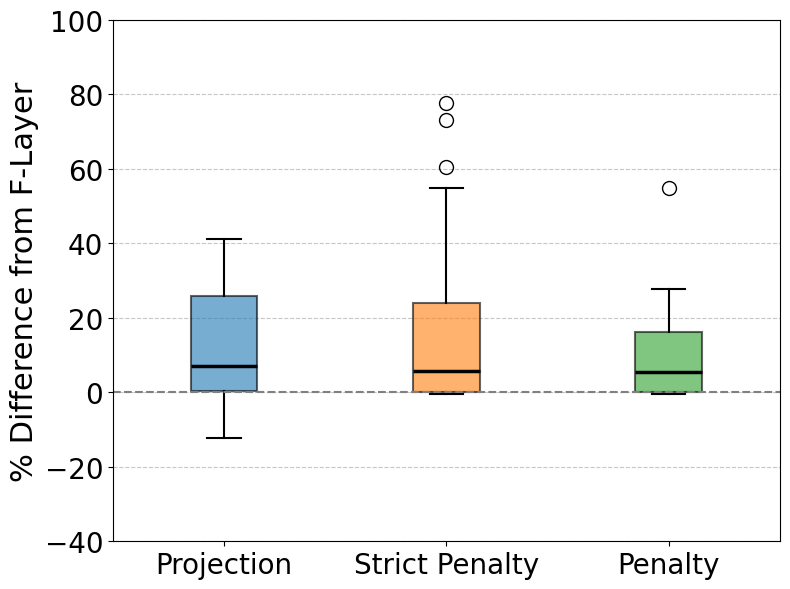

In [ ]:
data = []

with open(file_path, 'r') as f:
    for line in f:
        parts = line.strip().split(',')
        method = parts[0]
        idx = int(parts[1])
        
        #extract all numbers including scientific notation inside tensor(...)
        numbers = [float(x.replace("tensor(", "").replace(")", "")) 
                   for x in re.findall(r"[-+]?\d*\.\d+(?:[eE][-+]?\d+)?|[-+]?\d+", line)]
        
        if len(numbers) == 0:
            continue
        
        #For penalty methods, skip if 2nd-to-last number > get_slack() (i.e. didnt satisfy constr)
        if method == "penalty" and len(numbers) >= 2 and abs(numbers[-2]) > get_slack()+ .001:
            print(f"Skipping idx {idx} for penalty method due to constraint violation.")
            continue

        if method == "strict_penalty" and len(numbers) >= 2 and abs(numbers[-2]) > get_slack()+ .001:
            print(f"Skipping idx {idx} for strict_penalty method due to constraint violation.")
            continue
        
        if method == "baseline" and len(numbers) >= 2 and abs(numbers[-1]) > get_slack()+ .001:
            print(f"Skipping idx {idx} for baseline method due to constraint violation.")
            continue
        
        if method == "fair" and len(numbers) >= 2 and abs(numbers[-1]) > get_slack() + .001:
            print(f"Skipping idx {idx} for fair method due to constraint violation.")
            continue
        

        #Use last number as value
        if method == "fair":
            value = numbers[-2]
            data.append((method, idx, value))

        elif method == "baseline":
            value = numbers[2]
            data.append((method, idx, value))
        else:
            value = numbers[-1]
            data.append((method, idx, value))

df = pd.DataFrame(data, columns=['method', 'index', 'value'])
print(df)

#Get fair values indexed by dataset index
fair_df = df[df['method'] == 'fair'].set_index('index')['value']
methods = [m for m in df['method'].unique() if m != 'fair']

#Compute % difference vs fair for matching indices only
results = {}
for m in methods:
    method_df = df[df['method'] == m].set_index('index')['value']
    
    #Find common indices between this method and fair
    common_indices = method_df.index.intersection(fair_df.index)
    
    #Compute percentage differences only for common indices
    pct_diff = 100 * (method_df[common_indices] - fair_df[common_indices]) / fair_df[common_indices]
    results[m] = pct_diff.values


plt.figure(figsize=(8,6))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']  #blue, orange, green

label_map = {
    'baseline': 'Projection',
    'strict_penalty': 'Strict Penalty',
    'penalty': 'Penalty'
}

plot_labels = [label_map.get(m, m) for m in methods]

box = plt.boxplot(
    [results[m] for m in methods],
    labels=plot_labels,
    patch_artist=True,
    medianprops=dict(color='black', linewidth=2.5),
    boxprops=dict(linewidth=1.5),
    whiskerprops=dict(linewidth=1.5),
    capprops=dict(linewidth=1.5),
    flierprops=dict(marker='o', markersize=10,linewidth=1.5)
)


#Style boxes and fliers
for i, (patch, color) in enumerate(zip(box['boxes'], colors[:len(methods)])):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

plt.axhline(0, color='gray', linestyle='--')

plt.ylabel('% Difference from F-Layer', fontsize=22)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ylim([-40, 100])

plt.tight_layout()
plt.show()

#Dataset Metadata Analysis

In [ ]:
import os
import pickle
import pandas as pd
import re

folder_path = "./dataset_metadata"

#Get all dataset_*.pkl files
files = [
    f for f in os.listdir(folder_path)
    if re.match(r"dataset_\d+\.pkl$", f)
]

#Sort numerically by the number after "dataset_"
files.sort(key=lambda x: int(re.findall(r"\d+", x)[0]))

all_data = []

for filename in files:
    file_path = os.path.join(folder_path, filename)
    
    with open(file_path, "rb") as f:
        data = pickle.load(f)
    
    if isinstance(data, dict):
        row = data
    else:
        row = {
            attr: getattr(data, attr)
            for attr in dir(data)
            if not attr.startswith("_") and not callable(getattr(data, attr))
        }
    
    row["filename"] = filename
    all_data.append(row)

df = pd.DataFrame(all_data)
#Create DataFrame
df = pd.DataFrame(all_data).loc[:,['group_split','predictive_power','noise_level','constraint_tightness','data_type']]



,group_split,predictive_power,noise_level,constraint_tightness,data_type
0,low,low-medium,medium,loose,linear
1,low,low-medium,medium,loose,nonlinear
2,low,low-medium,medium,tight,linear
3,low,low-medium,medium,tight,nonlinear
4,low,low-medium,high,loose,linear
5,low,low-medium,high,loose,nonlinear
6,low,low-medium,high,tight,linear
7,low,low-medium,high,tight,nonlinear
8,low,high,medium,loose,linear
9,low,high,medium,loose,nonlinear


#Heatmaps

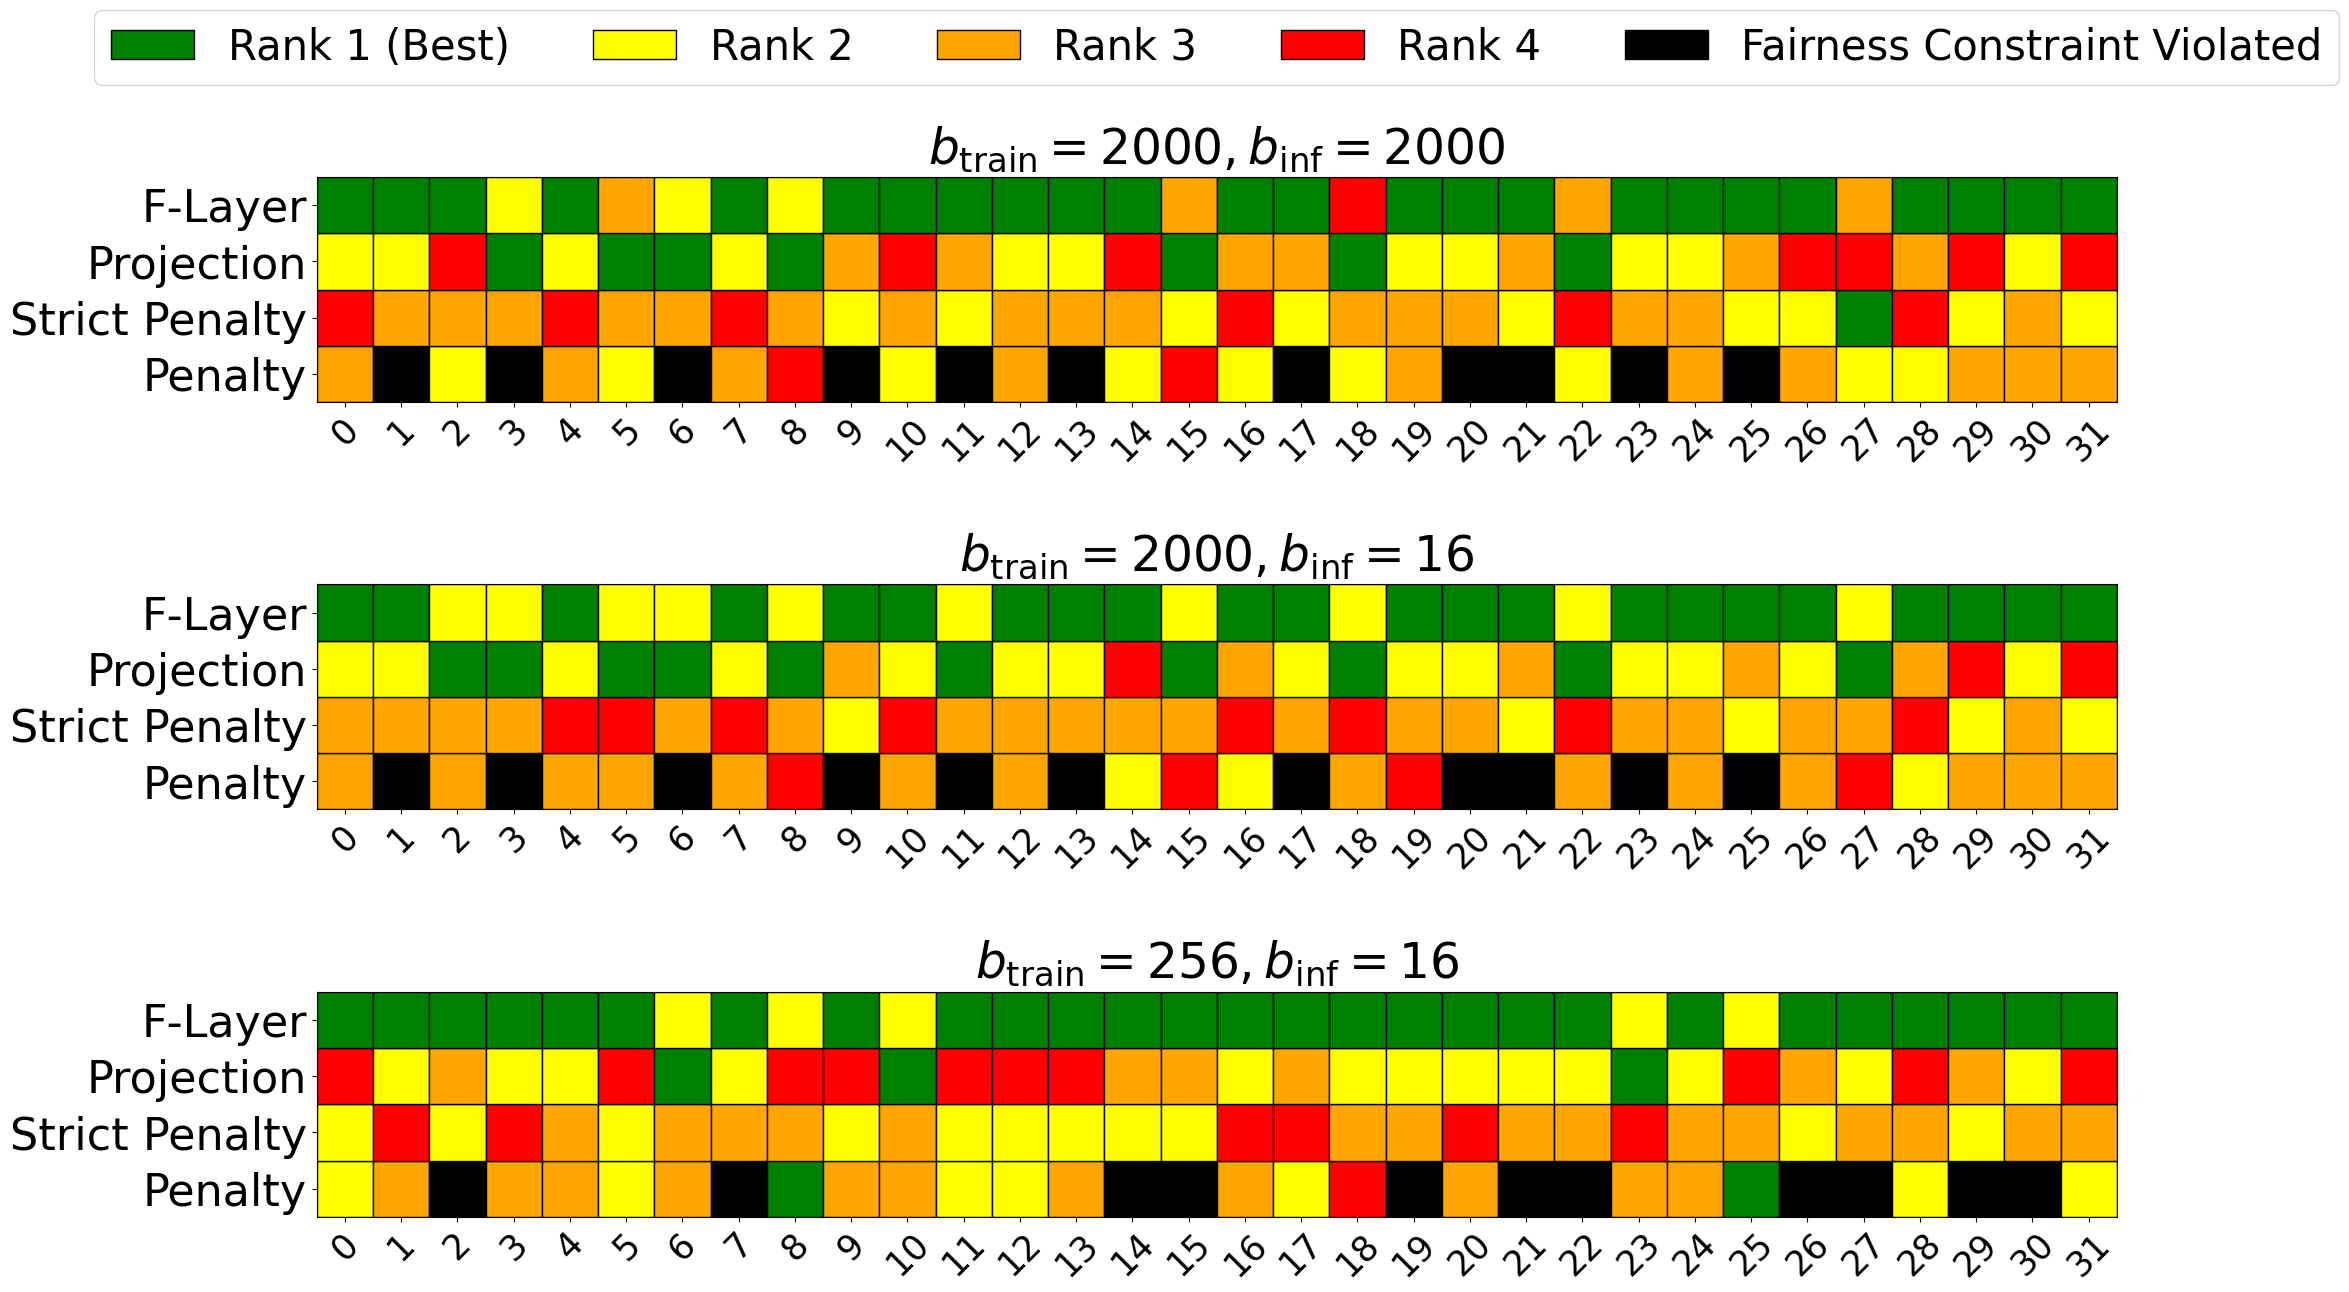

In [134]:
import pandas as pd
import re
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

file_paths = [
"./original_results/test_log_loss_large_batch.csv",
"./original_results/test_loss_log_2000_16.csv",
"./original_results/test_loss_log_256_16.csv"
]

titles = [
    r"$b_{\mathrm{train}} = 2000, b_{\mathrm{inf}} = 2000$",
    r"$b_{\mathrm{train}} = 2000, b_{\mathrm{inf}} = 16$",
    r"$b_{\mathrm{train}} = 256, b_{\mathrm{inf}} = 16$"
]

#Predefine label mapping and colors
label_map = {
    'baseline': 'Projection',
    'strict_penalty': 'Strict Penalty',
    'penalty': 'Penalty',
    'fair': 'F-Layer'
}
rank_colors = {1: 'green', 2: 'yellow', 3: 'orange', 4: 'red'}
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(20, 12))

for ax, file_path, title in zip(axes, file_paths, titles):
    data = []
    
    #parse csv
    with open(file_path, 'r') as f:
        for line in f:
            parts = line.strip().split(',')
            method = parts[0]
            idx = int(parts[1])
            numbers = [float(x.replace("tensor(", "").replace(")", "")) 
                       for x in re.findall(r"[-+]?\d*\.\d+(?:[eE][-+]?\d+)?|[-+]?\d+", line)]
            if len(numbers) == 0:
                continue

            if method == "penalty" or method == "strict_penalty":
                is_black = abs(numbers[-2]) > get_slack()+ .001
                value = numbers[-1]
        
            if method == "baseline":
                is_black = abs(numbers[-1]) > get_slack()+ .001
                value = numbers[-2]
        
            if method == "fair":
                is_black = abs(numbers[-1]) > get_slack()+ .001
                value = numbers[-2]

            data.append((method, idx, value, is_black))
    
    df = pd.DataFrame(data, columns=['method', 'dataset', 'value', 'is_black'])
    df['method_display'] = df['method'].map(label_map)
    
    pivot = df.pivot(index='dataset', columns='method_display', values='value')
    black_mask = df.pivot(index='dataset', columns='method_display', values='is_black').fillna(False)
    
    desired_order = ["Penalty", "Strict Penalty","Projection", "F-Layer"]
    pivot = pivot[desired_order]
    black_mask = black_mask[desired_order]
    
    #Compute ranks ignoring black cells
    ranks = pivot.copy()
    for i in range(ranks.shape[0]):
        row = pivot.iloc[i]
        mask = black_mask.iloc[i]
        non_black_values = row[~mask]
        row_ranks = non_black_values.rank(method='min', ascending=True)
        ranks.iloc[i, ~mask] = row_ranks
        ranks.iloc[i, mask] = np.nan
    
    #Build color matrix
    color_matrix = np.empty(ranks.shape, dtype=object)
    for i in range(ranks.shape[0]):
        for j, method in enumerate(ranks.columns):
            if black_mask.iloc[i, j]:
                color_matrix[i, j] = 'black'
            else:
                r = ranks.iloc[i, j]
                color_matrix[i, j] = rank_colors.get(int(r), 'red')
    
    #Plot heatmap
    for i in range(ranks.shape[0]):      #datasets
        for j in range(ranks.shape[1]):  #methods
            rect = plt.Rectangle(
                (i-0.5, j-0.5), 1, 1,
                facecolor=color_matrix[i, j],
                edgecolor='black',
                linewidth=1.0,
                zorder=2
            )
            ax.add_patch(rect)
    
    ax.set_xlim(-0.5, ranks.shape[0]-0.5)
    ax.set_ylim(-0.5, ranks.shape[1]-0.5)
    ax.set_xticks(range(ranks.shape[0]))
    ax.set_xticklabels(ranks.index, rotation=45, fontsize=25)
    ax.set_yticks(range(ranks.shape[1]))
    ax.set_yticklabels(ranks.columns, fontsize=32)
    ax.set_aspect('equal')  #Keep square cells
    ax.set_facecolor('white')
    ax.set_title(title, fontsize=32, fontweight='bold')

#Move titles up slightly with pad
for ax, title in zip(axes, titles):
    ax.set_title(title, fontsize=35, fontweight='bold', pad=10)

#Reduce margins to bring plots closer
plt.subplots_adjust(top=0.96, bottom=0.02, left=get_slack(), right=0.95, hspace=0.3)

#Add shared legend above all plots
legend_elements = [
    Patch(facecolor='green', edgecolor='black', label='Rank 1 (Best)'),
    Patch(facecolor='yellow', edgecolor='black', label='Rank 2'),
    Patch(facecolor='orange', edgecolor='black', label='Rank 3'),
    Patch(facecolor='red', edgecolor='black', label='Rank 4'),
    Patch(facecolor='black', edgecolor='black', label='Fairness Constraint Violated')
]

fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 1.08), ncol=5, fontsize=30)

plt.show()